# HW3: Simple Structure from Motion
## Two-View Pipeline (SIFT + Essential Matrix + Triangulation)

### Pipeline Overview
1. **Step 1: Camera Intrinsics** (`K`)
2. **Step 2: SIFT Feature Detection**
3. **Step 3: Feature Matching (L2 + NNDR)**
4. **Step 4: RANSAC on Essential Matrix**
5. **Step 5: Triangulate Inliers (Sparse 3D)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from intrinsics import compute_K
from features import get_sift_features, match_features
from ransac import RANSAC
from triangulation import triangulate_with_reprojection_filter

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)

## Step 0: Load Input Images

Image 1: (960, 1280, 3), Image 2: (960, 1280, 3)


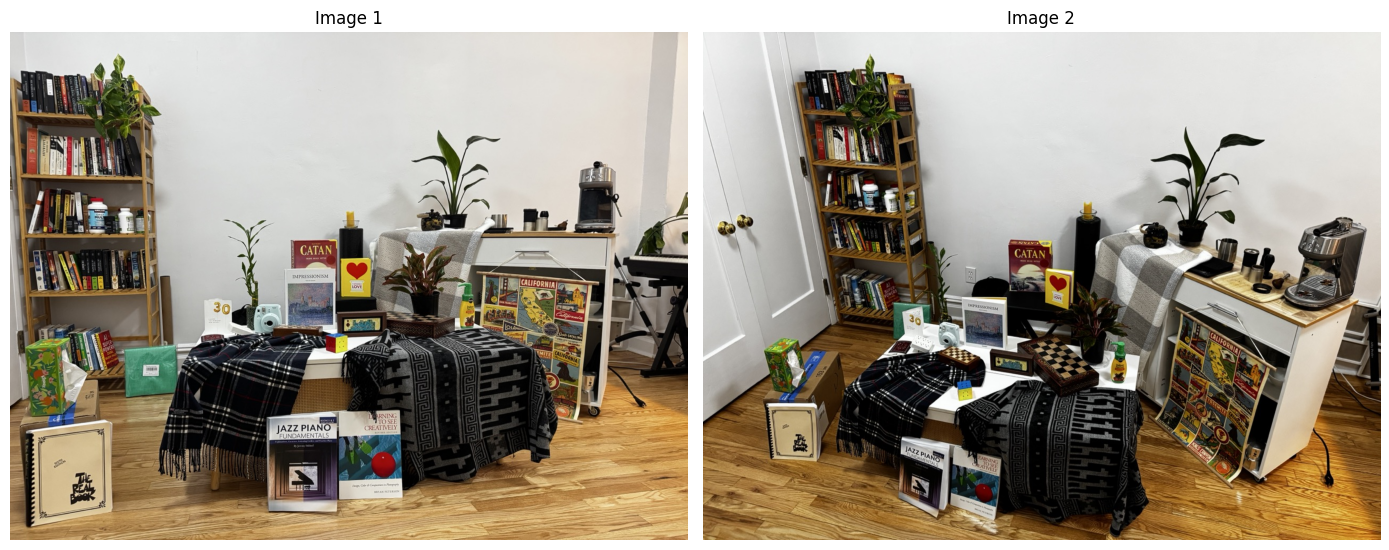

In [2]:
IMG1_PATH = "images/input/img1.jpeg"
IMG2_PATH = "images/input/img2.jpeg"
OUTPUT_DIR = "images/output/hw3"
os.makedirs(OUTPUT_DIR, exist_ok=True)

img1 = np.array(Image.open(IMG1_PATH).convert("RGB"))
img2 = np.array(Image.open(IMG2_PATH).convert("RGB"))
img1_gray = np.array(Image.open(IMG1_PATH).convert("L"))
img2_gray = np.array(Image.open(IMG2_PATH).convert("L"))

print(f"Image 1: {img1.shape}, Image 2: {img2.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img1)
axes[0].set_title("Image 1")
axes[0].axis("off")
axes[1].imshow(img2)
axes[1].set_title("Image 2")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Step 1: Compute Camera Intrinsics `K`

In [3]:
optical_focal_length_mm = 6.765
sensor_width_mm = 9.757
sensor_height_mm = 7.318

h_px, w_px = img1_gray.shape
K = compute_K(
    img_width_px=w_px,
    img_height_px=h_px,
    optical_focal_length_mm=optical_focal_length_mm,
    sensor_width_mm=sensor_width_mm,
    sensor_height_mm=sensor_height_mm,
)

print("Camera intrinsic matrix K:")
print(K)

Camera intrinsic matrix K:
[[887.47074826   0.         640.        ]
 [  0.         887.47074826 480.        ]
 [  0.           0.           1.        ]]


## Step 2: SIFT Feature Detection

SIFT features: image1=1198, image2=1197


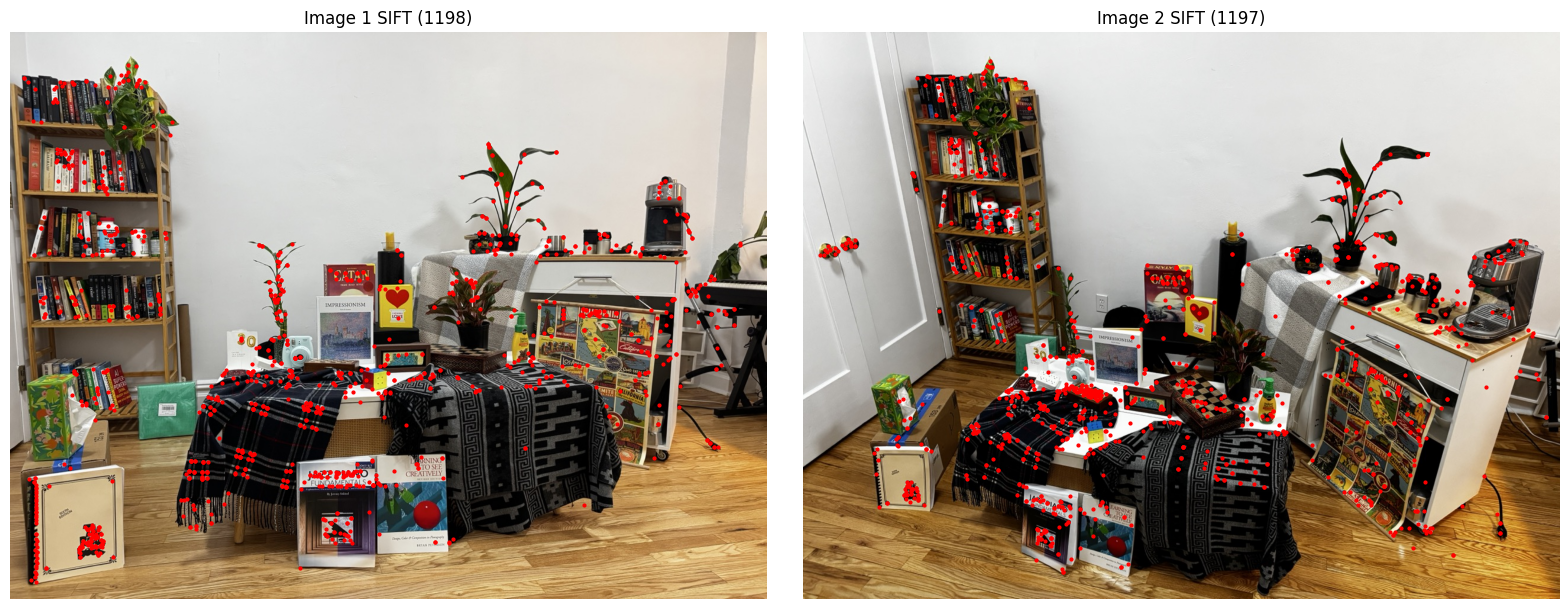

In [4]:
sift_max_features = 1200
sift_edge_discard = 20
sift_contrast_threshold = 0.04
sift_edge_threshold = 10
sift_n_octave_layers = 3
sift_sigma = 1.6

corners1, desc1, resp1 = get_sift_features(
    img1_gray,
    edge_discard=sift_edge_discard,
    max_features=sift_max_features,
    contrast_threshold=sift_contrast_threshold,
    edge_threshold=sift_edge_threshold,
    n_octave_layers=sift_n_octave_layers,
    sigma=sift_sigma,
)

corners2, desc2, resp2 = get_sift_features(
    img2_gray,
    edge_discard=sift_edge_discard,
    max_features=sift_max_features,
    contrast_threshold=sift_contrast_threshold,
    edge_threshold=sift_edge_threshold,
    n_octave_layers=sift_n_octave_layers,
    sigma=sift_sigma,
)

keypoints1 = corners1.T
keypoints2 = corners2.T

print(f"SIFT features: image1={keypoints1.shape[0]}, image2={keypoints2.shape[0]}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img1)
if keypoints1.shape[0] > 0:
    axes[0].scatter(keypoints1[:, 1], keypoints1[:, 0], s=4, c='r')
axes[0].set_title(f"Image 1 SIFT ({keypoints1.shape[0]})")
axes[0].axis("off")

axes[1].imshow(img2)
if keypoints2.shape[0] > 0:
    axes[1].scatter(keypoints2[:, 1], keypoints2[:, 0], s=4, c='r')
axes[1].set_title(f"Image 2 SIFT ({keypoints2.shape[0]})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Step 3: Feature Matching (L2 + NNDR)

Correspondences after NNDR: 139


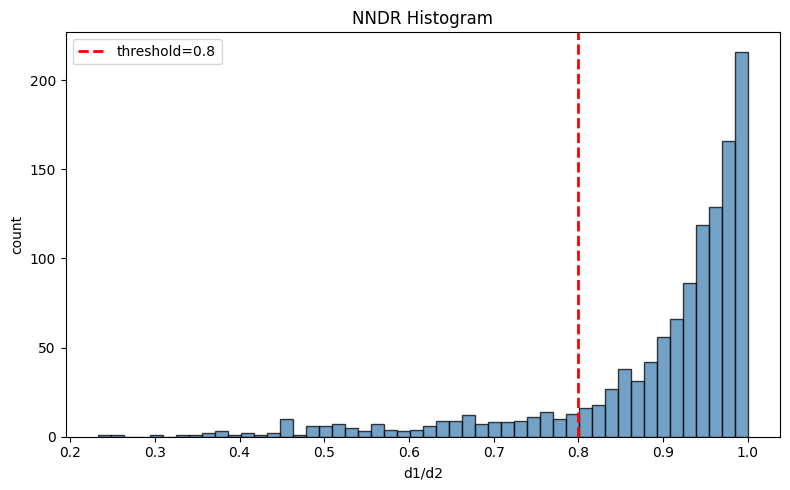

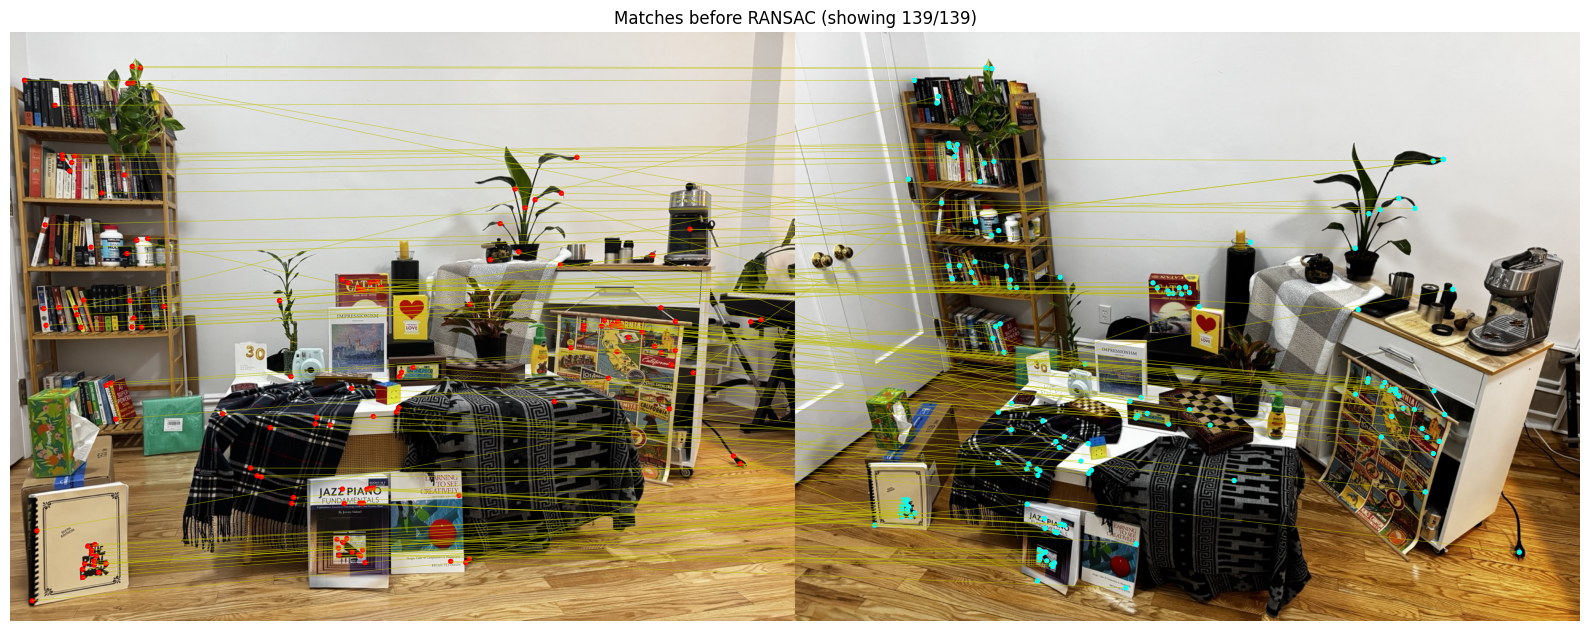

In [5]:
ratio_threshold = 0.8
correspondence_pairs, knn_matches, nndr = match_features(
    desc1, desc2, keypoints1, keypoints2, ratio_threshold=ratio_threshold
)

num_corr = len(correspondence_pairs)
print(f"Correspondences after NNDR: {num_corr}")

if len(nndr) > 0:
    plt.figure(figsize=(8, 5))
    plt.hist(nndr, bins=50, color='steelblue', edgecolor='black', alpha=0.75)
    plt.axvline(ratio_threshold, color='red', linestyle='--', linewidth=2, label=f"threshold={ratio_threshold}")
    plt.title("NNDR Histogram")
    plt.xlabel("d1/d2")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(16, 7))
combined = np.hstack([img1, img2])
ax.imshow(combined)
_, w1 = img1.shape[:2]
plot_n = min(num_corr, 150)
for i in range(plot_n):
    y1, x1 = correspondence_pairs[i, 0]
    y2, x2 = correspondence_pairs[i, 1]
    x2s = x2 + w1
    ax.plot([x1, x2s], [y1, y2], 'y-', linewidth=0.5, alpha=0.6)
    ax.scatter([x1, x2s], [y1, y2], s=8, c=['red', 'cyan'])
ax.set_title(f"Matches before RANSAC (showing {plot_n}/{num_corr})")
ax.axis("off")
plt.tight_layout()
plt.show()

## Step 4: RANSAC on Essential Matrix

RANSAC inliers: 106/139
R:
[[ 0.91525902 -0.07340281  0.39612239]
 [ 0.1811089   0.95327041 -0.24181624]
 [-0.35986176  0.29306578  0.88578325]]
t:
[-0.77202529  0.52942324  0.35169302]


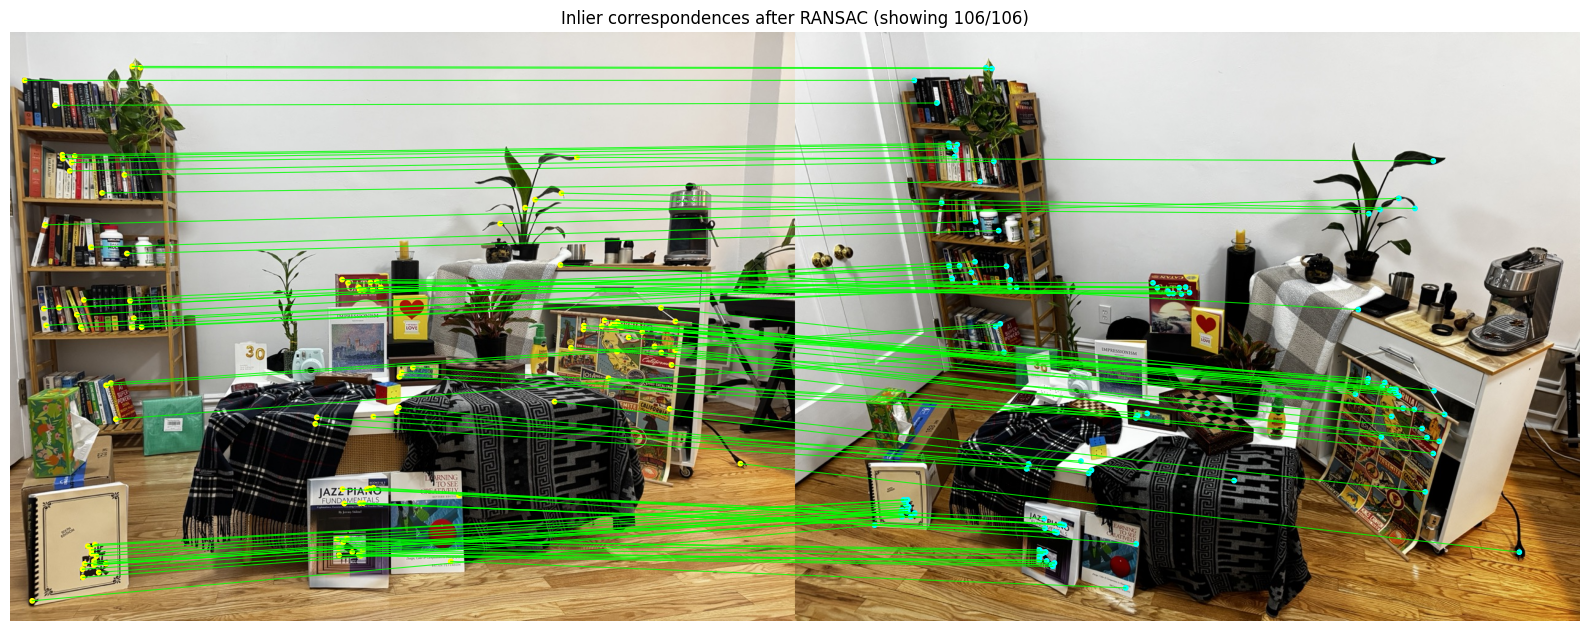

In [6]:
ransac_s = 8
ransac_epsilon = 2e-4
ransac_num_iters = 2000

R, t, inliers_mask, E, points_3d_ransac = RANSAC(
    correspondence_pairs=correspondence_pairs,
    K=K,
    s=ransac_s,
    epsilon=ransac_epsilon,
    num_iters=ransac_num_iters,
    output_dir=OUTPUT_DIR,
)

if R is None:
    raise RuntimeError("RANSAC failed to recover a valid pose")

inlier_correspondences = correspondence_pairs[inliers_mask]
num_inliers = int(np.sum(inliers_mask))
print(f"RANSAC inliers: {num_inliers}/{len(correspondence_pairs)}")
print("R:")
print(R)
print("t:")
print(t)

fig, ax = plt.subplots(figsize=(16, 7))
combined = np.hstack([img1, img2])
ax.imshow(combined)
_, w1 = img1.shape[:2]
plot_n = min(num_inliers, 150)
for i in range(plot_n):
    y1, x1 = inlier_correspondences[i, 0]
    y2, x2 = inlier_correspondences[i, 1]
    x2s = x2 + w1
    ax.plot([x1, x2s], [y1, y2], 'lime', linewidth=0.8, alpha=0.8)
    ax.scatter([x1, x2s], [y1, y2], s=10, c=['yellow', 'cyan'])
ax.set_title(f"Inlier correspondences after RANSAC (showing {plot_n}/{num_inliers})")
ax.axis("off")
plt.tight_layout()
plt.show()

## Step 5: Triangulate Inliers (Sparse 3D Point Cloud)

Triangulated: 106, valid: 106
Final valid 3D points: 106
Reprojection error stats (all): min=0.15, mean=2.97, median=3.03, max=8.93


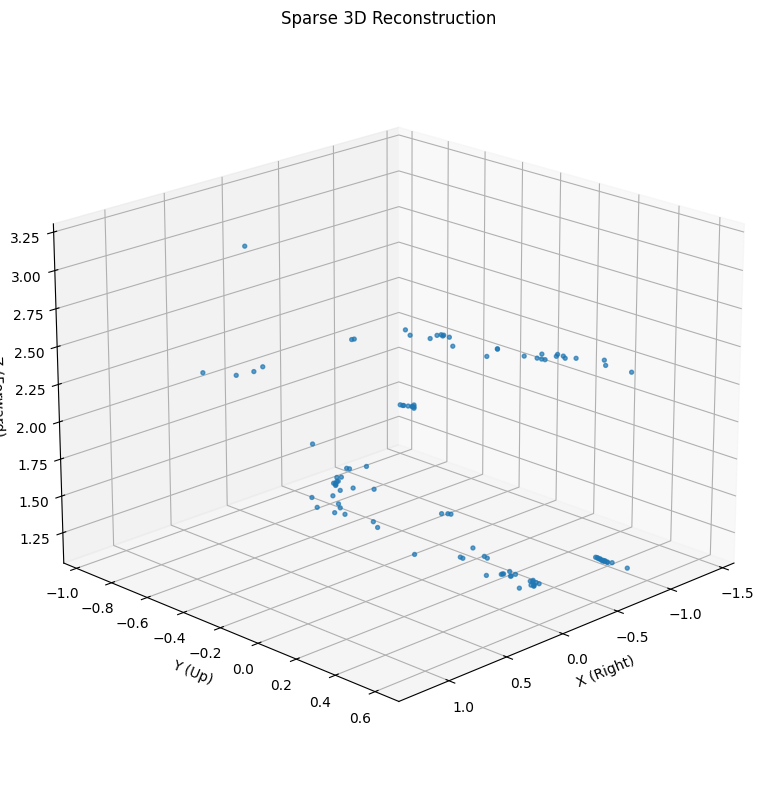

In [7]:
inlier_pts1 = inlier_correspondences[:, 0]
inlier_pts2 = inlier_correspondences[:, 1]

points_3d, valid_3d_mask_subset, reproj_errors = triangulate_with_reprojection_filter(
    R, t, inlier_pts1, inlier_pts2, K,
    max_reprojection_error=50.0,
    min_depth=0.01,
    max_depth=10000.0,
    verbose=True,
)

print(f"Final valid 3D points: {len(points_3d)}")
if len(reproj_errors) > 0:
    print(
        f"Reprojection error stats (all): "
        f"min={reproj_errors.min():.2f}, "
        f"mean={reproj_errors.mean():.2f}, "
        f"median={np.median(reproj_errors):.2f}, "
        f"max={reproj_errors.max():.2f}"
    )

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
if len(points_3d) > 0:
    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], s=8, alpha=0.7)
ax.set_xlabel("X (Right)")
ax.set_ylabel("Y (Up)")
ax.set_zlabel("Z (Forward)")
ax.set_title("Sparse 3D Reconstruction")
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

## Deliverables: 3 Triangulation Views (with Cameras + Captions)

This cell saves three screenshots in `images/output/hw3/` that match the HW3 deliverable style:
- both cameras visible in each view
- sparse point cloud from different angles
- caption text below each subplot

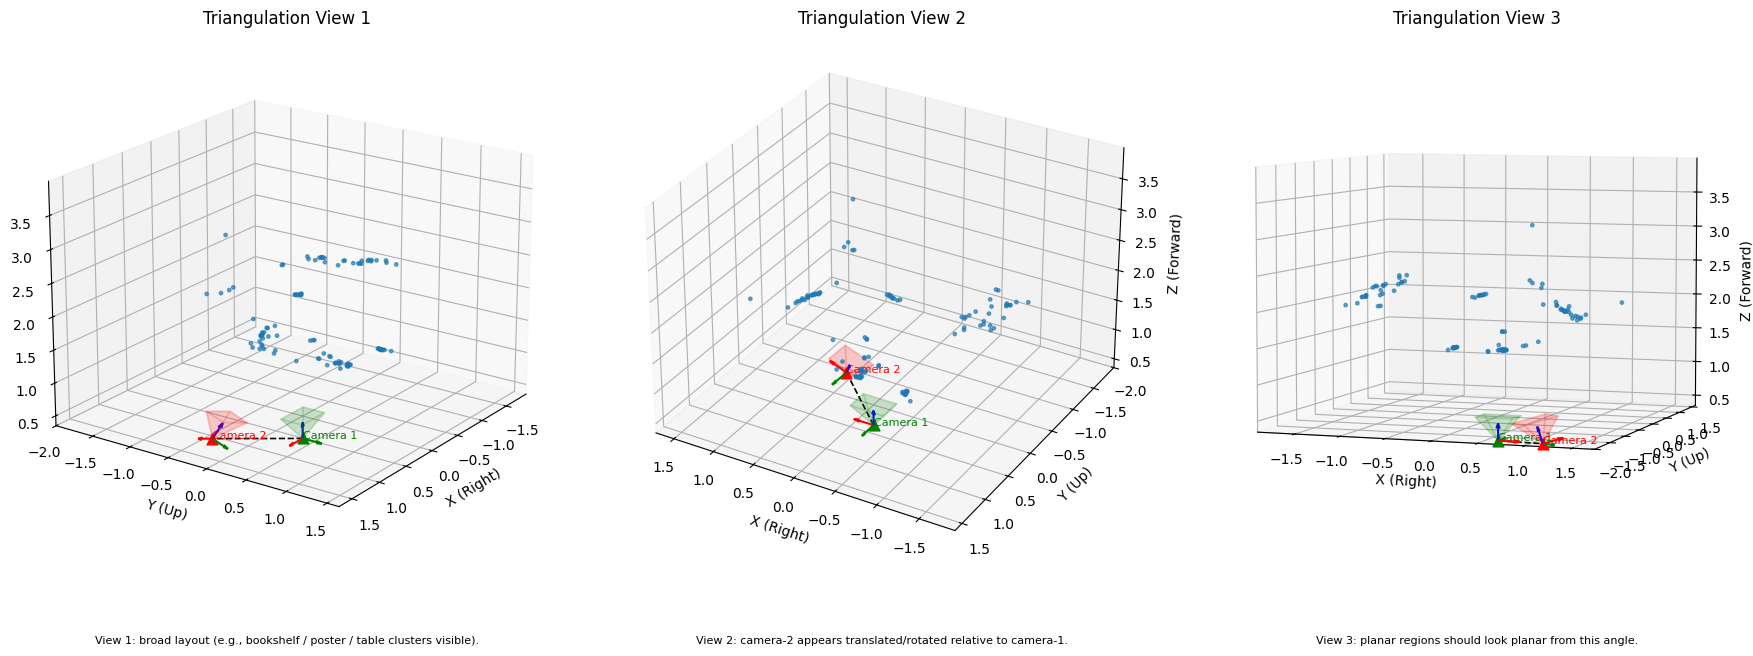

Saved:
 - images/output/hw3\triangulation_3views_with_cameras.png
 - images/output/hw3\triangulation_view_1.png
 - images/output/hw3\triangulation_view_2.png
 - images/output/hw3\triangulation_view_3.png


In [8]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def camera_center_from_rt(R_wc, t_wc):
    return -R_wc.T @ t_wc


def build_frustum(C, R_c2w, scale=0.25):
    # Local camera frustum corners in camera coordinates
    # OpenCV convention: +Z forward
    z = 1.0 * scale
    w = 0.6 * scale
    h = 0.4 * scale
    corners_cam = np.array([
        [0, 0, 0],
        [-w, -h, z],
        [ w, -h, z],
        [ w,  h, z],
        [-w,  h, z],
    ])
    corners_world = (R_c2w @ corners_cam.T).T + C
    return corners_world


def draw_camera(ax, C, R_c2w, color='green', name='Camera'):
    fr = build_frustum(C, R_c2w, scale=0.35)
    apex = fr[0]
    base = fr[1:]

    # Pyramid faces
    faces = [
        [apex, base[0], base[1]],
        [apex, base[1], base[2]],
        [apex, base[2], base[3]],
        [apex, base[3], base[0]],
        [base[0], base[1], base[2], base[3]],
    ]
    poly = Poly3DCollection(faces, alpha=0.10, facecolor=color, edgecolor=color, linewidths=1.2)
    ax.add_collection3d(poly)

    ax.scatter(*C, color=color, s=60, marker='^')
    ax.text(C[0], C[1], C[2], name, color=color, fontsize=8)

    # Camera axes
    axis_len = 0.25
    ax.quiver(*C, *(R_c2w[:, 0] * axis_len), color='r', linewidth=1.5)  # +X
    ax.quiver(*C, *(R_c2w[:, 1] * axis_len), color='g', linewidth=1.5)  # +Y
    ax.quiver(*C, *(R_c2w[:, 2] * axis_len), color='b', linewidth=1.5)  # +Z


# Camera 1 (reference) in world = identity
C0 = np.zeros(3)
R0_c2w = np.eye(3)

# Camera 2 from recovered [R|t] (world->cam2), convert to c2w
C1 = camera_center_from_rt(R, t)
R1_c2w = R.T

views = [
    (20, 35,  "View 1: broad layout (e.g., bookshelf / poster / table clusters visible)."),
    (30, 120, "View 2: camera-2 appears translated/rotated relative to camera-1."),
    (5,  -70, "View 3: planar regions should look planar from this angle."),
]

fig = plt.figure(figsize=(18, 6))
for idx, (elev, azim, caption) in enumerate(views, start=1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')

    if len(points_3d) > 0:
        ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], s=6, alpha=0.65)

    draw_camera(ax, C0, R0_c2w, color='green', name='Camera 1')
    draw_camera(ax, C1, R1_c2w, color='red', name='Camera 2')

    # Baseline line
    ax.plot([C0[0], C1[0]], [C0[1], C1[1]], [C0[2], C1[2]], 'k--', linewidth=1.2)

    ax.set_title(f"Triangulation View {idx}")
    ax.set_xlabel('X (Right)')
    ax.set_ylabel('Y (Up)')
    ax.set_zlabel('Z (Forward)')
    ax.view_init(elev=elev, azim=azim)

    # Equal-ish axis scaling
    if len(points_3d) > 0:
        mins = np.min(points_3d, axis=0)
        maxs = np.max(points_3d, axis=0)
        ctr = (mins + maxs) / 2.0
        r = np.max(maxs - mins) / 2.0 + 0.5
        ax.set_xlim(ctr[0] - r, ctr[0] + r)
        ax.set_ylim(ctr[1] - r, ctr[1] + r)
        ax.set_zlim(ctr[2] - r, ctr[2] + r)

    ax.text2D(0.5, -0.15, caption, transform=ax.transAxes, ha='center', fontsize=8)

plt.tight_layout()
combined_path = os.path.join(OUTPUT_DIR, 'triangulation_3views_with_cameras.png')
plt.savefig(combined_path, dpi=220, bbox_inches='tight')
plt.show()

# Also save individual views for report insertion
for idx, (elev, azim, caption) in enumerate(views, start=1):
    fig_i = plt.figure(figsize=(7, 6))
    ax_i = fig_i.add_subplot(111, projection='3d')
    if len(points_3d) > 0:
        ax_i.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], s=8, alpha=0.7)
    draw_camera(ax_i, C0, R0_c2w, color='green', name='Camera 1')
    draw_camera(ax_i, C1, R1_c2w, color='red', name='Camera 2')
    ax_i.plot([C0[0], C1[0]], [C0[1], C1[1]], [C0[2], C1[2]], 'k--', linewidth=1.2)
    ax_i.set_title(f"Triangulation View {idx}")
    ax_i.set_xlabel('X (Right)')
    ax_i.set_ylabel('Y (Up)')
    ax_i.set_zlabel('Z (Forward)')
    ax_i.view_init(elev=elev, azim=azim)
    ax_i.text2D(0.5, -0.10, caption, transform=ax_i.transAxes, ha='center', fontsize=9)
    path_i = os.path.join(OUTPUT_DIR, f'triangulation_view_{idx}.png')
    plt.savefig(path_i, dpi=220, bbox_inches='tight')
    plt.close(fig_i)

print('Saved:')
print(' -', combined_path)
for idx in range(1, 4):
    print(' -', os.path.join(OUTPUT_DIR, f'triangulation_view_{idx}.png'))

## Export Scene for Viser (Required for HW3 screenshots)

This exports a scene file and prints the exact command to open Viser for capturing the 3 required screenshots.

In [9]:
# Build camera poses (camera-to-world) from recovered R,t
T0 = np.eye(4)
T1 = np.eye(4)
T1[:3, :3] = R.T
T1[:3, 3] = (-R.T @ t).flatten()
camera_poses = np.stack([T0, T1])

# Keep colors for valid triangulated points using image-1 correspondences
valid_corr = inlier_correspondences[valid_3d_mask_subset]
point_colors = []
for pt in valid_corr[:, 0, :]:
    y, x = int(pt[0]), int(pt[1])
    y = np.clip(y, 0, img1.shape[0] - 1)
    x = np.clip(x, 0, img1.shape[1] - 1)
    point_colors.append(img1[y, x, :3])
point_colors = np.array(point_colors)

baseline = float(np.linalg.norm(t))
scene_npz = os.path.join(OUTPUT_DIR, "step5_scene_data.npz")
np.savez(
    scene_npz,
    points_3d=points_3d,
    point_colors=point_colors,
    camera_poses=camera_poses,
    K=K,
    R=R,
    t=t,
    img1=img1,
    img2=img2,
    num_inliers=int(np.sum(inliers_mask)),
    baseline=baseline,
)

print("Saved scene file:", scene_npz)
print("Run this for Viser screenshots:")
print(f"python visualize_viser.py {scene_npz}")
print("\nScreenshot checklist:")
print("1) Keep Point Cloud + Cameras + Camera Images visible")
print("2) Take 3 different view angles")
print("3) Add captions naming landmarks visible in each screenshot")

Saved scene file: images/output/hw3\step5_scene_data.npz
Run this for Viser screenshots:
python visualize_viser.py images/output/hw3\step5_scene_data.npz

Screenshot checklist:
1) Keep Point Cloud + Cameras + Camera Images visible
2) Take 3 different view angles
3) Add captions naming landmarks visible in each screenshot


## Interactive Viser Viewer (inside notebook)

This moves the Viser visualization helpers into the notebook so you can launch the viewer directly from `main.ipynb` after exporting `scene_npz`.

In [10]:
import time
import numpy as np
import viser


def _make_server(start_port: int = 8081, max_tries: int = 50):
    port = start_port
    for _ in range(max_tries):
        try:
            server = viser.ViserServer(port=port)
            return server, port
        except OSError:
            port += 1
    raise RuntimeError(f"Could not bind a Viser server port after {max_tries} attempts")


def visualize_scene(npz_path: str, port: int = 8081, block: bool = False):
    data = np.load(npz_path, allow_pickle=True)

    points_3d = data["points_3d"]
    point_colors = data.get("point_colors", None)
    camera_poses = data["camera_poses"]  # (2, 4, 4), camera-to-world
    K = data["K"]

    img1 = data.get("img1", None)
    img2 = data.get("img2", None)

    num_inliers = int(data.get("num_inliers", 0))
    baseline = float(data.get("baseline", 0.0))

    if point_colors is None or len(point_colors) != len(points_3d):
        point_colors = np.tile(np.array([[0.2, 0.6, 1.0]]), (len(points_3d), 1))
    elif point_colors.max() > 1.0:
        point_colors = point_colors / 255.0

    server, actual_port = _make_server(port)
    print(f"Viser running at: http://localhost:{actual_port}")
    print("Open the URL above in your browser.")

    cam0_forward = camera_poses[0][:3, 2]
    cam0_up = -camera_poses[0][:3, 1]

    @server.on_client_connect
    def _(client: viser.ClientHandle) -> None:
        client.camera.position = -cam0_forward * 2.5 + cam0_up * 0.6
        client.camera.look_at = np.zeros(3)
        client.camera.up_direction = cam0_up

    pc_handle = server.scene.add_point_cloud(
        name="/point_cloud",
        points=points_3d,
        colors=point_colors,
        point_size=0.01,
    )

    camera_names = ["Camera 1 (Reference)", "Camera 2"]
    camera_colors = [(0, 255, 0), (255, 0, 0)]
    camera_images = [img1, img2]

    frustums = []
    labels = []
    images = []

    for i, (T, name, color, img) in enumerate(zip(camera_poses, camera_names, camera_colors, camera_images)):
        R_c2w = T[:3, :3]
        pos = T[:3, 3]

        fy = K[1, 1]
        if img is not None:
            img_h = img.shape[0]
            fov = 2 * np.arctan(img_h / (2 * fy))
            aspect = img.shape[1] / img.shape[0]
        else:
            cy = K[1, 2]
            fov = 2 * np.arctan(cy / fy)
            aspect = 1.0

        fr = server.scene.add_camera_frustum(
            name=f"/camera_{i}",
            fov=fov,
            aspect=aspect,
            scale=0.3,
            wxyz=viser.transforms.SO3.from_matrix(R_c2w).wxyz,
            position=pos,
            color=color,
        )
        frustums.append(fr)

        labels.append(
            server.scene.add_label(
                name=f"/camera_{i}_label",
                text=name,
                position=pos + np.array([0, 0, 0.15]),
            )
        )

        if img is not None:
            img_uint8 = (img * 255).astype(np.uint8) if img.dtype != np.uint8 and img.max() <= 1.0 else img.astype(np.uint8)
            if img_uint8.ndim == 2:
                img_uint8 = np.stack([img_uint8] * 3, axis=-1)

            image_distance = 0.5
            image_height = 2 * image_distance * np.tan(fov / 2)
            image_width = image_height * aspect
            forward = R_c2w[:, 2]
            image_center = pos + forward * image_distance

            images.append(
                server.scene.add_image(
                    name=f"/camera_{i}_image",
                    image=img_uint8,
                    render_width=image_width,
                    render_height=image_height,
                    wxyz=viser.transforms.SO3.from_matrix(R_c2w).wxyz,
                    position=image_center,
                )
            )
        else:
            images.append(None)

    server.scene.add_frame(
        name="/world",
        wxyz=(1.0, 0.0, 0.0, 0.0),
        position=np.array([0.0, 0.0, 0.0]),
        axes_length=0.3,
        axes_radius=0.01,
    )

    baseline_handle = server.scene.add_spline_catmull_rom(
        name="/baseline",
        positions=np.array([camera_poses[0][:3, 3], camera_poses[1][:3, 3]]),
        color=(255, 255, 0),
        line_width=3.0,
    )

    with server.gui.add_folder("Scene Info"):
        server.gui.add_text("Points", initial_value=str(len(points_3d)), disabled=True)
        server.gui.add_text("Inliers", initial_value=str(num_inliers), disabled=True)
        server.gui.add_text("Baseline", initial_value=f"{baseline:.4f}", disabled=True)

    with server.gui.add_folder("Visibility"):
        pc_vis = server.gui.add_checkbox("Point Cloud", initial_value=True)
        cam_vis = server.gui.add_checkbox("Cameras", initial_value=True)
        img_vis = server.gui.add_checkbox("Camera Images", initial_value=True)
        bl_vis = server.gui.add_checkbox("Baseline", initial_value=True)

        @pc_vis.on_update
        def _(_evt):
            pc_handle.visible = pc_vis.value

        @cam_vis.on_update
        def _(_evt):
            for h in frustums:
                h.visible = cam_vis.value
            for h in labels:
                h.visible = cam_vis.value

        @img_vis.on_update
        def _(_evt):
            for h in images:
                if h is not None:
                    h.visible = img_vis.value

        @bl_vis.on_update
        def _(_evt):
            baseline_handle.visible = bl_vis.value

    if block:
        try:
            while True:
                time.sleep(0.1)
        except KeyboardInterrupt:
            print("Stopping Viser server...")

    return server

In [11]:
# Run after the scene export cell has created `scene_npz`
server = visualize_scene(scene_npz, port=8081, block=False)
server

╭────── viser (listening *:8081) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

Viser running at: http://localhost:8081
Open the URL above in your browser.


(viser) Connection opened (0, 1 total), 39 persistent messages